# 01 — Exploration : TWS Forecasting (Zindi Drought Challenge)

Objectifs de ce notebook (Phase 1 du roadmap, voir `doc/PROJECT_BRIEF.md` section 5) :
1. Statistiques descriptives (train vs test).
2. Valeurs manquantes.
3. **Mesure empirique de la distribution des horizons effectifs dans le test** (essentielle pour la Phase 3).
4. Cartes de couverture spatiale.
5. Analyse saisonnière et corrélations à différents lags.

Règle anti-leakage rappelée : `lat`, `lon`, `ID`/`sample_id` ne sont jamais des features de modèle,
uniquement des clés de groupe. Ce notebook les utilise donc uniquement pour l'exploration, jamais
comme input d'un modèle.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG = yaml.safe_load((PROJECT_ROOT / "configs" / "base.yaml").read_text())
RAW_DIR = PROJECT_ROOT / CONFIG["paths"]["raw_dir"]
SEED = CONFIG["seed"]
np.random.seed(SEED)

RAW_DIR

WindowsPath('C:/Users/user/Documents/PERSO/ZINDI/DROUGHT ZINDI COMPETITION/data/raw')

## 1. Chargement des données

In [2]:
train = pd.read_csv(RAW_DIR / "Train.csv", parse_dates=["time"])
test = pd.read_csv(RAW_DIR / "Test.csv", parse_dates=["time"])
sample_sub = pd.read_csv(RAW_DIR / "SampleSubmission.csv")

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")
print(f"Sample submission : {sample_sub.shape}")

Train : (2154021, 13)
Test  : (280961, 13)
Sample submission : (280961, 2)


In [3]:
train.head(3)

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.5,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.5,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.5,-0.866025,-0.337083


In [4]:
test.head(3)

,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,TWS_t_masked
0,20150901_-55.5_-68.5,2015-09-01,-55.5,-68.5,-0.373966,-0.024582,0.958610,0.549351,1.264457,-0.474105,-1.0,-1.836970e-16,False
1,20150901_-55.5_-67.5,2015-09-01,-55.5,-67.5,-0.530701,-0.049041,1.070304,0.526642,1.267029,-0.217645,-1.0,-1.836970e-16,False
2,20150901_-54.5_-71.5,2015-09-01,-54.5,-71.5,0.531723,0.661190,1.189847,0.924421,0.851582,-0.574531,-1.0,-1.836970e-16,False


**Remarque de structure** : le train n'a pas de colonne `TWS_t_masked` (toutes les valeurs y
sont réelles), le test n'a pas de colonne `target` (à prédire) et introduit `TWS_t_masked`.
La colonne id s'appelle `sample_id` en train et `ID` en test — à harmoniser en Phase 2.

## 2. Statistiques descriptives

In [5]:
num_cols = ["TWS_t", "SPEI_01_t", "SPEI_03_t", "SPEI_06_t", "SPEI_12_t", "SOIL_MOISTURE_t"]

desc_train = train[num_cols + ["target"]].describe().T
desc_train

,count,mean,std,min,25%,50%,75%,max
TWS_t,2154021.0,0.116995,0.913025,-3.968328,-0.526700,0.131532,0.785811,4.057275
SPEI_01_t,2154021.0,-0.030368,0.956504,-4.247924,-0.748531,-0.055874,0.666071,3.475902
SPEI_03_t,2154021.0,-0.055324,0.944398,-5.225329,-0.761128,-0.076110,0.631382,4.177270
SPEI_06_t,2154021.0,-0.070566,0.939890,-4.383301,-0.769565,-0.089408,0.609807,4.850391
SPEI_12_t,2154021.0,-0.093270,0.930651,-4.622383,-0.779340,-0.113459,0.574957,3.764673
SOIL_MOISTURE_t,2154021.0,0.000779,0.787456,-5.107245,-0.445176,0.000655,0.502670,5.385165
target,2154021.0,0.112504,0.911962,-3.968328,-0.529442,0.127302,0.780707,4.057275


In [6]:
desc_test = test[num_cols].describe().T
desc_test

,count,mean,std,min,25%,50%,75%,max
TWS_t,94048.0,-0.051049,0.957270,-3.263359,-0.674276,-0.170790,0.572820,3.701359
SPEI_01_t,280961.0,-0.009498,0.976780,-4.199318,-0.747989,-0.032112,0.706383,3.096373
SPEI_03_t,280961.0,-0.034009,1.003526,-4.273445,-0.791332,-0.045108,0.707291,3.309473
SPEI_06_t,280961.0,-0.056483,0.998345,-3.706275,-0.817281,-0.059016,0.689928,2.973456
SPEI_12_t,280961.0,-0.114175,0.976346,-3.847257,-0.861551,-0.115639,0.621200,3.253553
SOIL_MOISTURE_t,280961.0,0.031105,0.843641,-5.318862,-0.419456,0.058956,0.574705,5.334668


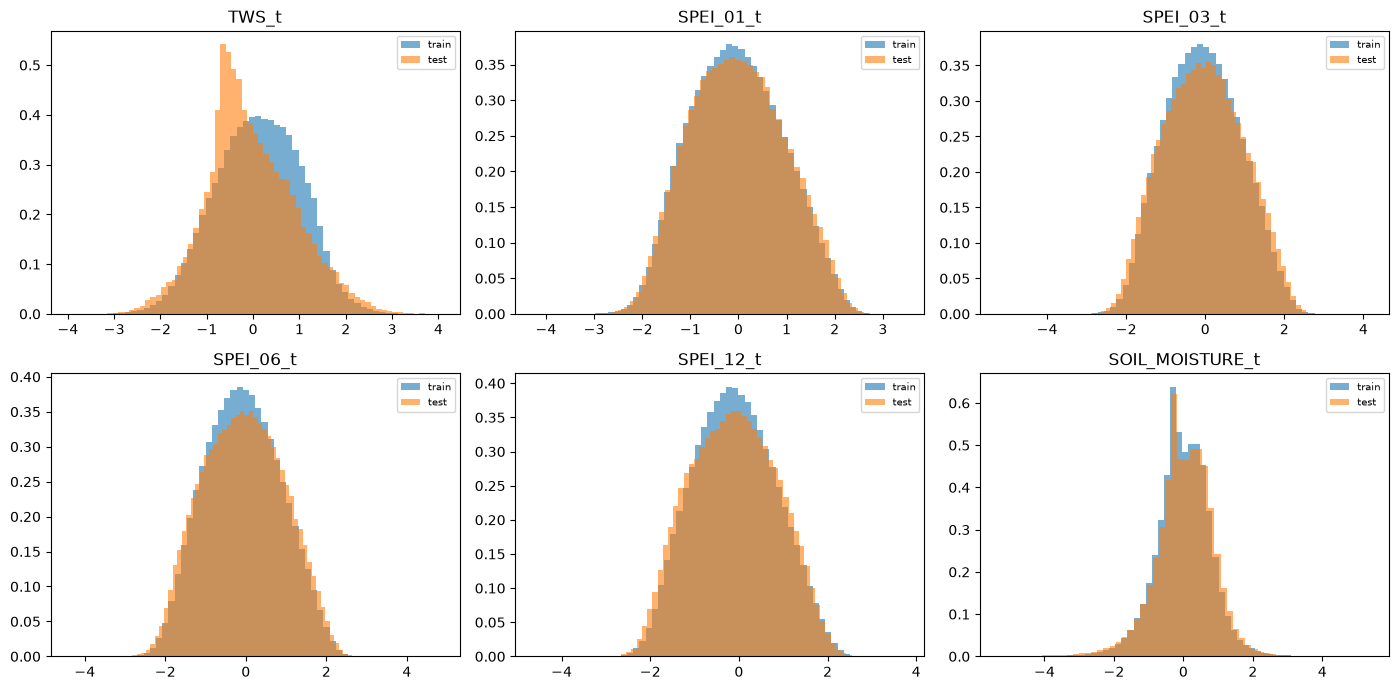

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(train[col].dropna(), bins=60, alpha=0.6, label="train", density=True)
    ax.hist(test[col].dropna(), bins=60, alpha=0.6, label="test", density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "fig_distributions.png", bbox_inches="tight")
plt.show()

Les covariables sont déjà standardisées (moyenne proche de 0, écart-type proche de 1) :
vraisemblablement une normalisation par cellule ou globale appliquée en amont par les organisateurs.
Les distributions train/test se superposent bien, pas de dérive flagrante.

## 3. Valeurs manquantes

In [8]:
missing_train = train.isna().mean().sort_values(ascending=False) * 100
missing_test = test.isna().mean().sort_values(ascending=False) * 100

pd.DataFrame({"train_%_missing": missing_train, "test_%_missing": missing_test})

,train_%_missing,test_%_missing
ID,NaN,0.000000
SOIL_MOISTURE_t,0.0,0.000000
SPEI_01_t,0.0,0.000000
SPEI_03_t,0.0,0.000000
SPEI_06_t,0.0,0.000000
SPEI_12_t,0.0,0.000000
TWS_t,0.0,66.526315
TWS_t_masked,NaN,0.000000
lat,0.0,0.000000
lon,0.0,0.000000


In [9]:
masked_share = test["TWS_t_masked"].mean() * 100
print(f"Part des lignes test avec TWS_t masqué : {masked_share:.1f}%")
print("(Le brief indique ~66.5% — sert de garde-fou de cohérence.)")

Part des lignes test avec TWS_t masqué : 66.5%
(Le brief indique ~66.5% — sert de garde-fou de cohérence.)


`TWS_t` n'est jamais `NaN` explicitement : le masquage se traduit par une valeur numérique
substituée (probablement une estimation ou un remplissage), signalée uniquement par le booléen
`TWS_t_masked`. **Ne jamais utiliser `TWS_t` sans vérifier ce flag.**

## 4. Horizon effectif dans le test

Définition (brief section 2.4) :

```
horizon_effectif = (t+1) − (dernier mois où TWS_t est observé pour cette cellule)
```

Calcul **sans aucune fuite** : on utilise uniquement `TWS_t_masked` (jamais les valeurs de `TWS_t`
ou de `target`). Pour une ligne **non masquée**, `TWS_t` de cette ligne est par définition observé à
son propre mois `t` ⇒ horizon = 1. Pour une ligne **masquée**, on remonte à la dernière date (train ou
test antérieur) où cette cellule avait un `TWS_t` observé.

In [10]:
train_last_observed = train.groupby(["lat", "lon"])["time"].max().to_dict()

test_sorted = test.sort_values(["lat", "lon", "time"]).reset_index(drop=True)
horizons = np.empty(len(test_sorted), dtype="int32")

for (lat, lon), g in test_sorted.groupby(["lat", "lon"], sort=False):
    last_observed = train_last_observed.get((lat, lon))
    idx = g.index.to_numpy()
    times = g["time"].to_numpy()
    masked = g["TWS_t_masked"].to_numpy()
    for i in range(len(idx)):
        t = pd.Timestamp(times[i])
        if masked[i]:
            h = (t.year - last_observed.year) * 12 + (t.month - last_observed.month) + 1
        else:
            h = 1
            last_observed = t
        horizons[idx[i]] = h

test_sorted["horizon_effectif"] = horizons
test = test.merge(
    test_sorted[["lat", "lon", "time", "horizon_effectif"]],
    on=["lat", "lon", "time"],
    how="left",
)
test["horizon_effectif"].describe()

count    280961.000000
mean          2.714341
std           1.785385
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max           7.000000
Name: horizon_effectif, dtype: float64

In [11]:
horizon_counts = test["horizon_effectif"].value_counts().sort_index()
horizon_counts

horizon_effectif
1    94048
2    62576
3    46777
4    31076
5    15560
6    15479
7    15445
Name: count, dtype: int64

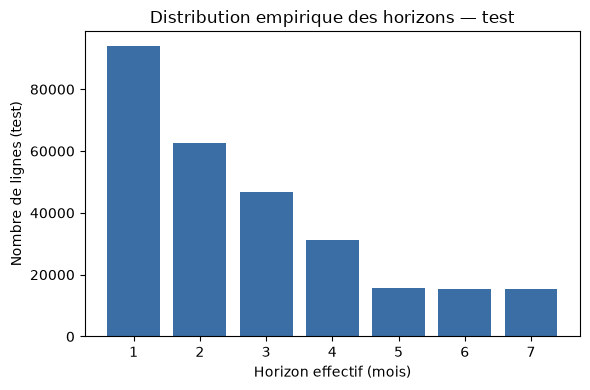

OK : horizon effectif dans [1, 7], conforme au brief.


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(horizon_counts.index, horizon_counts.values, color="#3b6ea5")
ax.set_xlabel("Horizon effectif (mois)")
ax.set_ylabel("Nombre de lignes (test)")
ax.set_title("Distribution empirique des horizons — test")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "fig_horizon_distribution.png", bbox_inches="tight")
plt.show()

assert test["horizon_effectif"].min() == 1
assert test["horizon_effectif"].max() == 7, "Horizon hors de la plage 1-7 attendue par le brief"
print("OK : horizon effectif dans [1, 7], conforme au brief.")

Cette distribution sera sauvegardée en Phase 3 (`configs/horizon_distribution.yaml` ou
équivalent) pour piloter le masquage augmenté à l'entraînement, avec la même logique cumulative
(on masque toujours les N mois les plus récents d'une cellule).

## 5. Couverture spatiale

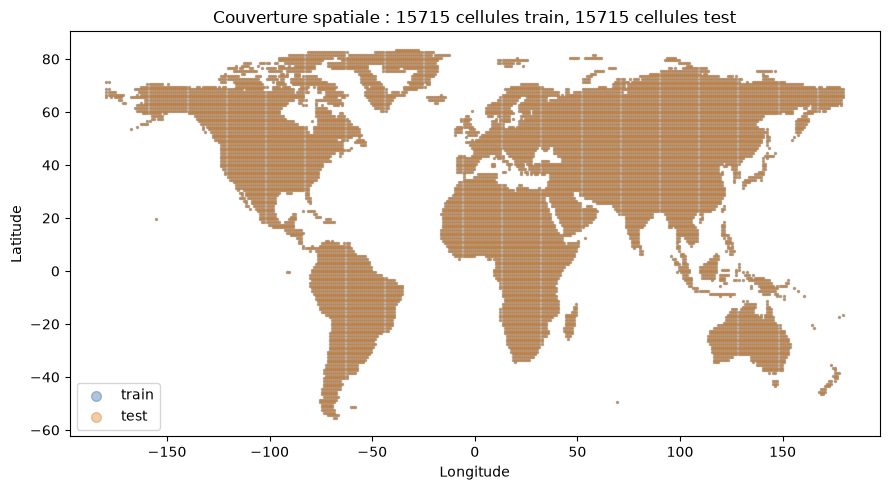

In [13]:
cells_train = train[["lat", "lon"]].drop_duplicates()
cells_test = test[["lat", "lon"]].drop_duplicates()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(cells_train["lon"], cells_train["lat"], s=2, alpha=0.4, label="train", color="#3b6ea5")
ax.scatter(cells_test["lon"], cells_test["lat"], s=2, alpha=0.4, label="test", color="#d9822b")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Couverture spatiale : {len(cells_train)} cellules train, {len(cells_test)} cellules test")
ax.legend(markerscale=5)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "fig_spatial_coverage.png", bbox_inches="tight")
plt.show()

In [14]:
only_train = cells_train.merge(cells_test, on=["lat", "lon"], how="left", indicator=True)
only_train = only_train[only_train["_merge"] == "left_only"]
only_test = cells_test.merge(cells_train, on=["lat", "lon"], how="left", indicator=True)
only_test = only_test[only_test["_merge"] == "left_only"]
print(f"Cellules présentes seulement en train : {len(only_train)}")
print(f"Cellules présentes seulement en test  : {len(only_test)}")

Cellules présentes seulement en train : 0
Cellules présentes seulement en test  : 0


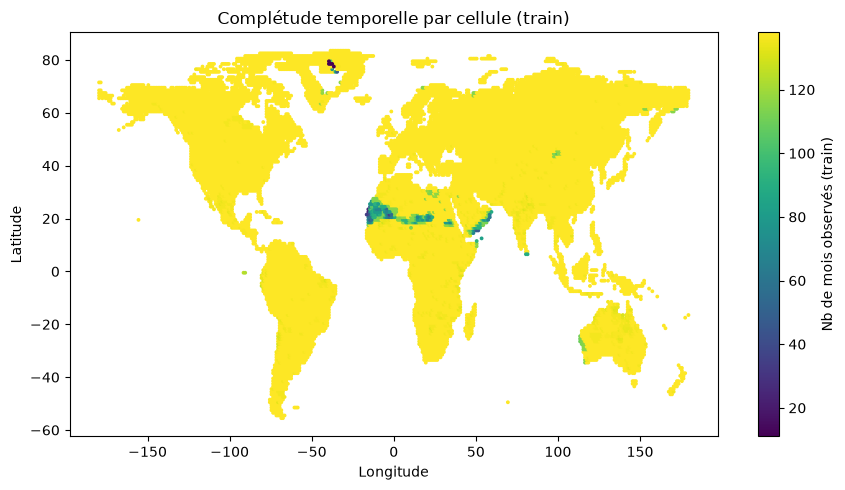

Cellules avec couverture temporelle incomplète (< 138 mois) : 1157 / 15715


In [15]:
n_months_per_cell = train.groupby(["lat", "lon"])["time"].nunique()

fig, ax = plt.subplots(figsize=(9, 5))
sca = ax.scatter(
    train[["lat", "lon"]].drop_duplicates()["lon"],
    train[["lat", "lon"]].drop_duplicates()["lat"],
    c=n_months_per_cell.reindex(
        pd.MultiIndex.from_frame(train[["lat", "lon"]].drop_duplicates())
    ).values,
    s=3,
    cmap="viridis",
)
plt.colorbar(sca, ax=ax, label="Nb de mois observés (train)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Complétude temporelle par cellule (train)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "fig_temporal_completeness_map.png", bbox_inches="tight")
plt.show()

print(f"Cellules avec couverture temporelle incomplète (< 138 mois) : "
      f"{(n_months_per_cell < n_months_per_cell.max()).sum()} / {len(n_months_per_cell)}")

La grille est quasi complète et régulière (essentiellement des continents, pas d'océans — cohérent
avec un produit GRACE de stockage d'eau terrestre). Une minorité de cellules a une couverture
temporelle incomplète en train (vu en section 0 : 7 dates de dernier mois différentes) — à
surveiller lors du split temporel (Phase 4).

## 6. Analyse saisonnière

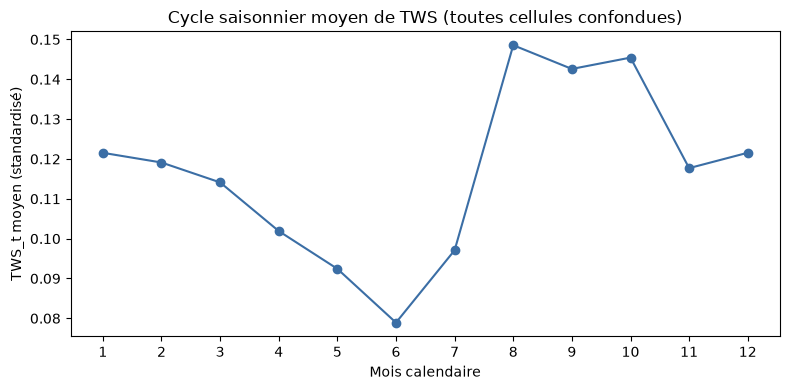

In [16]:
train["month"] = train["time"].dt.month
clim = train.groupby("month")[["TWS_t"] + num_cols[1:]].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(clim.index, clim["TWS_t"], marker="o", color="#3b6ea5")
ax.set_xlabel("Mois calendaire")
ax.set_ylabel("TWS_t moyen (standardisé)")
ax.set_title("Cycle saisonnier moyen de TWS (toutes cellules confondues)")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "fig_seasonal_cycle.png", bbox_inches="tight")
plt.show()

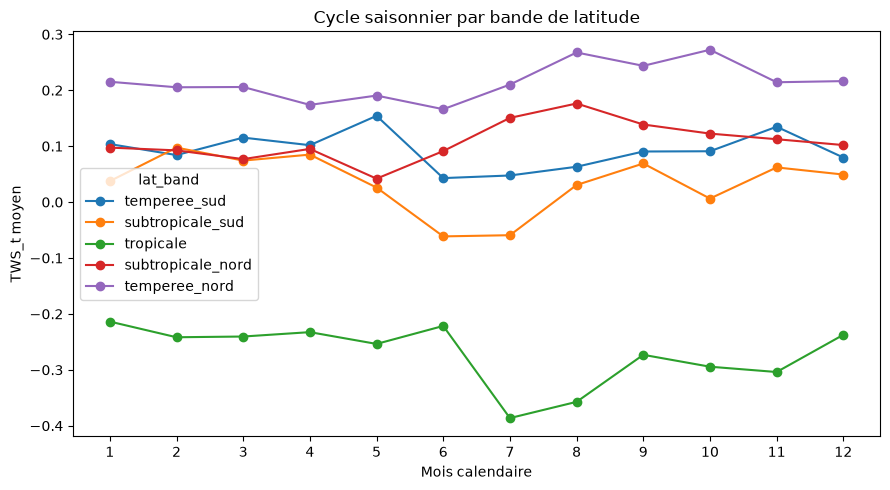

In [17]:
# Cycle saisonnier par bande de latitude (hémisphère nord vs sud, tropiques)
train["lat_band"] = pd.cut(
    train["lat"],
    bins=[-90, -35, -10, 10, 35, 90],
    labels=["temperee_sud", "subtropicale_sud", "tropicale", "subtropicale_nord", "temperee_nord"],
)
clim_band = train.groupby(["lat_band", "month"], observed=True)["TWS_t"].mean().unstack("lat_band")

fig, ax = plt.subplots(figsize=(9, 5))
clim_band.plot(ax=ax, marker="o")
ax.set_xlabel("Mois calendaire")
ax.set_ylabel("TWS_t moyen")
ax.set_title("Cycle saisonnier par bande de latitude")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "fig_seasonal_by_latband.png", bbox_inches="tight")
plt.show()

On observe des cycles saisonniers **opposés en phase** entre hémisphères nord et sud (décalage
d'environ 6 mois), cohérent avec les cycles hydrologiques liés aux saisons. La bande tropicale a un
cycle plus atténué. Ceci justifie fortement une feature de climatologie par cellule/mois en Phase 2
(`seasonal.py`), plutôt qu'une climatologie globale.

## 7. Corrélations à différents lags

In [18]:
train_sorted = train.sort_values(["lat", "lon", "time"]).reset_index(drop=True)
g = train_sorted.groupby(["lat", "lon"])["TWS_t"]

for lag in [1, 3, 6, 12]:
    train_sorted[f"TWS_t_lag{lag}"] = g.shift(lag)

lag_cols = [f"TWS_t_lag{lag}" for lag in [1, 3, 6, 12]]
corr_with_target = train_sorted[["target"] + lag_cols + ["TWS_t"]].corr()["target"].drop("target")
corr_with_target.sort_values(ascending=False)

TWS_t          0.803260
TWS_t_lag1     0.719707
TWS_t_lag3     0.629153
TWS_t_lag6     0.509943
TWS_t_lag12    0.371310
Name: target, dtype: float64

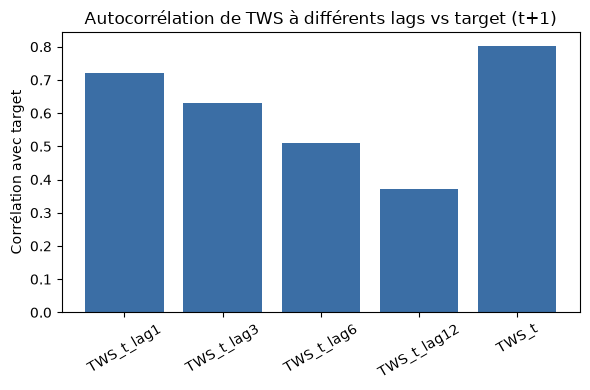

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(corr_with_target.index, corr_with_target.values, color="#3b6ea5")
ax.set_ylabel("Corrélation avec target")
ax.set_title("Autocorrélation de TWS à différents lags vs target (t+1)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "fig_lag_correlations.png", bbox_inches="tight")
plt.show()

In [20]:
corr_covariates = train[num_cols + ["target"]].corr()["target"].drop("target").sort_values(ascending=False)
corr_covariates

TWS_t              0.803260
SPEI_12_t          0.379573
SPEI_06_t          0.368248
SOIL_MOISTURE_t    0.320483
SPEI_03_t          0.285371
SPEI_01_t          0.203882
Name: target, dtype: float64

`TWS_t` (lag 0, persistance) est de loin le meilleur prédicteur linéaire de `target`, comme
attendu de la baseline de persistance. La corrélation décroît avec le lag mais reste significative à
12 mois, ce qui confirme l'intérêt d'une feature interannuelle (`TWS_t − TWS_{t-12}`) en Phase 2.
Parmi les covariables, `SOIL_MOISTURE_t` et les `SPEI` de courte fenêtre (01, 03) sont les plus
corrélées à la target après `TWS_t` lui-même.

## 8. Synthèse

In [21]:
summary = f'''
- Train : {train.shape[0]:,} lignes, {train[["lat","lon"]].drop_duplicates().shape[0]:,} cellules, {train["time"].nunique()} mois (2002-05 -> 2015-08).
- Test  : {test.shape[0]:,} lignes, {test[["lat","lon"]].drop_duplicates().shape[0]:,} cellules, {test["time"].nunique()} mois (2015-09 -> 2018-12).
- TWS_t masque dans {masked_share:.1f}% des lignes test (brief: ~66.5%).
- Horizon effectif mesure sans fuite : min={test["horizon_effectif"].min()}, max={test["horizon_effectif"].max()}, moyenne={test["horizon_effectif"].mean():.2f}.
- Distribution horizon (test) : {horizon_counts.to_dict()}
- Corrélation target vs TWS_t (lag0) : {corr_with_target["TWS_t"]:.3f}
- Corrélation target vs TWS_t_lag12 : {corr_with_target["TWS_t_lag12"]:.3f}
'''
print(summary)


- Train : 2,154,021 lignes, 15,715 cellules, 138 mois (2002-05 -> 2015-08).
- Test  : 280,961 lignes, 15,715 cellules, 18 mois (2015-09 -> 2018-12).
- TWS_t masque dans 66.5% des lignes test (brief: ~66.5%).
- Horizon effectif mesure sans fuite : min=1, max=7, moyenne=2.71.
- Distribution horizon (test) : {1: 94048, 2: 62576, 3: 46777, 4: 31076, 5: 15560, 6: 15479, 7: 15445}
- Corrélation target vs TWS_t (lag0) : 0.803
- Corrélation target vs TWS_t_lag12 : 0.371



**Prochaine étape** : ces résultats sont repris dans `reports/data_understanding.md`, et la
distribution des horizons servira de base au masquage augmenté (Phase 3). Le pipeline de features
(Phase 2) doit prioriser : lags temporels (1,3,6,12), climatologie par cellule/mois, feature
d'horizon explicite (`months_since_last_observed_tws`), et voisinage spatial.